# Tutorial 0: Data Preparation

This notebook covers the two essential data preparation steps before running any GRB population inference:

**A.** Loading and creating Fermi-GBM catalogue data  
**B.** Preparing redshift samples from Merger Rate Density (MRD) models

The outputs of this notebook will be used as inputs for the subsequent tutorials.

---

## Part A: Loading and Creating GBM Data

We use the `gdt-fermi` package (Fermi GBM Data Tools) to access the official Fermi-GBM Burst Catalog. This provides observed short GRB properties (peak flux, T90, fluence, peak energy) that serve as the observational constraints for our MCMC inference.

### The Burst Catalog

In [11]:
from gdt.missions.fermi.gbm.catalogs import BurstCatalog
import numpy as np
import matplotlib.pyplot as plt

# Initialize the Fermi-GBM burst catalog (downloads from HEASARC)
burstcat = BurstCatalog()
print(f"Total GRBs in catalogue: {burstcat.num_rows}")

Sending request and awaiting response from HEASARC...
Finished in 76 s
Total GRBs in catalogue: 4357


The catalogue contains many columns see the official Fermi website [here](https://heasarc.gsfc.nasa.gov/W3Browse/fermi/fermigbrst.html) for more details. The key observables for our analysis are:
- **`FLUX_BATSE_64`**: Peak photon flux in the 50–300 keV band (64 ms timescale)
- **`T90`**: Duration of the burst (time containing 90% of the fluence)
- **`FLUENCE_BATSE`**: Total fluence in the 50–300 keV band
- **`PFLX_COMP_EPEAK`**: Peak energy from the spectral fit

In [12]:
cols = [c.upper() for c in ["T90", "Flux_BATSE_64", "Fluence_BATSE", "Pflx_Comp_Epeak", "Trigger_Time"]]
burstcat.get_table(cols)

rec.array([( 4.288,  0.6028, 1.2524e-07, 205.7393 , 56020.856927  ),
           (17.408, 11.1926, 1.3652e-05, 204.6519 , 55984.72547517),
           (11.008,  2.6118, 8.9879e-07, 115.3316 , 60088.35730917), ...,
           ( 8.192,  3.2791, 1.6901e-06, 559.1635 , 55593.39942421),
           (29.184,  1.5475, 2.7596e-06,  81.31714, 59672.86295194),
           ( 0.304,  8.9562, 2.0602e-07, 554.5049 , 59389.04054685)],
          dtype=[('T90', '<f8'), ('FLUX_BATSE_64', '<f8'), ('FLUENCE_BATSE', '<f8'), ('PFLX_COMP_EPEAK', '<f8'), ('TRIGGER_TIME', '<f8')])

### Apply Selection Cuts

We select **short GRBs** ($T_{90} < 2\,\text{s}$) with a peak flux above a completeness threshold ($F_p > 4\,\text{ph/cm}^2/\text{s}$). These cuts define the "triggered" sample that our Monte Carlo must reproduce. We additionally add a quality cut $E_{\text{peak}} \in [50, 10^4]\,\text{keV}$.

In [13]:
# Define selection cuts
cond_t90  = ("T90",           0, 2)       # Short GRBs: T90 < 2s
cond_flux = ("Flux_BATSE_64", 4, 10_000)  # Peak flux > 4 ph/cm^2/s (completeness), the upper bound is arbitrary 
cond_energy = ("Pflx_Comp_Epeak"  , 50, 10_000) # Quality cut 

triggered_table = burstcat.slices([cond_flux, cond_t90])
quality_table   = burstcat.slices([cond_flux, cond_t90, cond_energy])

# Calculate the observation time and event rate
times       = triggered_table.get_table(columns=("trigger_time", "T90"))
trig_time   = times['TRIGGER_TIME']
trig_time_quality = quality_table.get_table(columns=("trigger_time", "T90"))['TRIGGER_TIME']

days_year   = 365.25
years       = (max(trig_time) - min(trig_time)) / days_year
event_rate  = len(trig_time) / years
event_rate_quality = len(trig_time_quality) / years

print(f"Total short GRBs passing cuts: {len(trig_time)}")
print(f"Observation span: {years:.2f} years")
print(f"Event rate: {event_rate:.2f} events/yr")
print(f"Event rate (quality cut): {event_rate_quality:.2f} events/yr")

from astropy.time import Time
# Convert trigger times from MET to UTC for display
trigger_times_utc = Time(trig_time, format='mjd', scale='tai').utc
print(f"Most recent trigger time (UTC): {trigger_times_utc[0].iso}")
print(f"First trigger time (UTC): {trigger_times_utc[-1].iso}")

Total short GRBs passing cuts: 333
Observation span: 17.94 years
Event rate: 18.57 events/yr
Event rate (quality cut): 14.94 events/yr
Most recent trigger time (UTC): 2026-07-10 12:58:06.521
First trigger time (UTC): 2021-06-24 00:57:46.248


### Save the Catalogue

We save the filtered catalogue in formats that are then read by the MCMC. 

In [14]:
import pandas as pd

# --- Save the filtered (triggered + fitted) catalogue as .txt ---
table_to_save = triggered_table.get_table(
    columns=("Flux_BATSE_64", "T90", "Fluence_BATSE", "Pflx_Comp_Epeak")
)

ev_rate_string = f"{event_rate:.2f}".replace(".", "_")
txt_filename = f"../datafiles/fermi_catalogue_{ev_rate_string}.txt"

np.savetxt(txt_filename, table_to_save)
print(f"Saved triggered catalogue to: {txt_filename}")

# --- Save ALL short GRBs (T90 < 2s, no flux cut) as .dat for catalogue_prep ---
cond_all_short = ("T90", 0, 2)
all_short_table = burstcat.slices([cond_all_short])
all_cols = ("Flux_BATSE_64", "T90", "Fluence_BATSE", "Pflx_Comp_Epeak", "TRIGGER_TIME")
all_table = all_short_table.get_table(columns=all_cols)

table_df = pd.DataFrame(all_table)
dat_filename = "../datafiles/burst_catalog.dat"
table_df.to_csv(dat_filename, index=False)
print(f"Saved full short GRB catalogue ({len(table_df)} rows) to: {dat_filename}")

Saved triggered catalogue to: ../datafiles/fermi_catalogue_18_57.txt
Saved full short GRB catalogue (730 rows) to: ../datafiles/burst_catalog.dat


### Visualize the Catalogue

A corner plot of the four key observables provides a quick sanity check of the data.

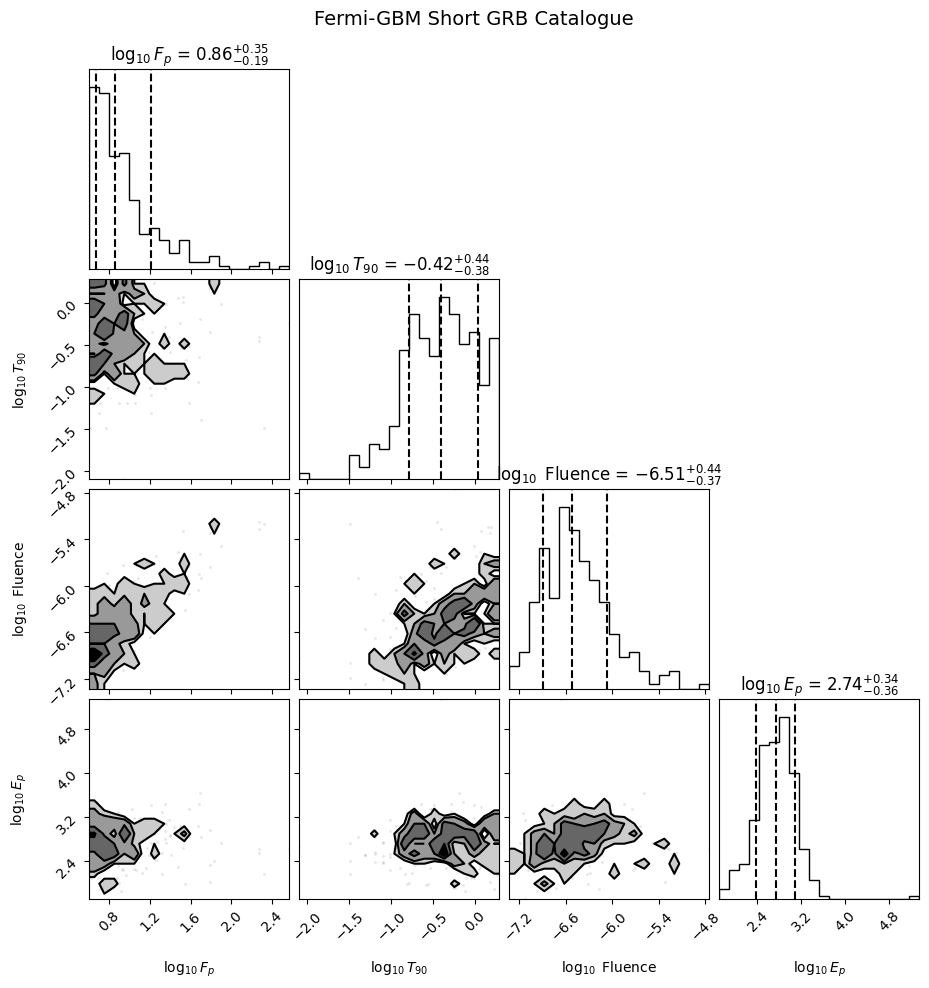

In [15]:
import corner

loaded_data = np.loadtxt(txt_filename)

epeak_linear = loaded_data[:, 3]
mask = epeak_linear > 0
pflx    = np.log10(loaded_data[:, 0][mask])
t90     = np.log10(loaded_data[:, 1][mask])
fluence = np.log10(loaded_data[:, 2][mask])
epeak   = np.log10(loaded_data[:, 3][mask])

fig = corner.corner(
    np.array([pflx, t90, fluence, epeak]).T,
    labels=[r"$\log_{10} F_p$", r"$\log_{10} T_{90}$", r"$\log_{10}$ Fluence", r"$\log_{10} E_p$"],
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 12},
    fill_contours=True,
)
plt.suptitle("Fermi-GBM Short GRB Catalogue", y=1.02, fontsize=14)
plt.show()

---

## Part B: Preparing Redshift Samples

The redshift distribution of BNS mergers is a critical ingredient. We use population synthesis models that predict the Merger Rate Density (MRD) $\mathcal{R}(z)\,[\text{Gpc}^{-3}\text{yr}^{-1}]$.

The probability of a merger at redshift $z$ is:

$$
P(z) = \frac{1}{N_{\text{total}}} \frac{\mathcal{R}(z)}{1+z} \frac{dV_c}{dz}
$$

where $dV_c/dz$ is the differential comoving volume and the $(1+z)^{-1}$ factor accounts for cosmological time dilation (as we are dealing with a rate $\text{yr}^{-1}$).

In [16]:
import notebook_setup

from pathlib import Path
from src.redshift import get_redshift_quantities

datafiles = Path("../datafiles")

mrd_path = datafiles / "MRD_outputs" / "fiducial_A1_0_BNS.csv"

total_rate, local_rate, z_grid, P_z_density = get_redshift_quantities(
    mrd_path=mrd_path
)

print(f"Local merger rate R_0:  {local_rate:.1f} Gpc^-3 yr^-1")
print(f"Total merger rate:      {total_rate:.0f} yr^-1 (integrated over all z)")

Local merger rate R_0:  113.7 Gpc^-3 yr^-1
Total merger rate:      358540 yr^-1 (integrated over all z)


### Merger Rate Density

Before sampling, let's compare how the MRD $\mathcal{R}(z)$ changes with the common-envelope efficiency parameter $\alpha$ for the fiducial model. Higher $\alpha$ allows more efficient envelope ejection, affecting the delay-time distribution and hence the redshift evolution of the merger rate.

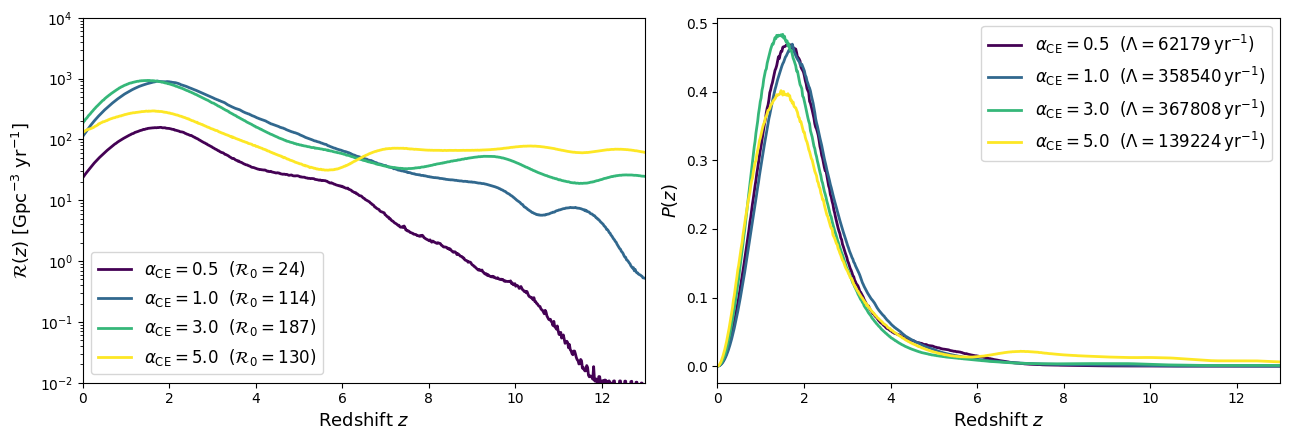

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

colors = {'A0.5': '#440154', 'A1.0': '#31688e', 'A3.0': '#35b779', 'A5.0': '#fde725'}
mrd_paths = [
    datafiles / "MRD_outputs" / f"fiducial_{alpha_val}_BNS.csv"
    for alpha_val in ["A0_5", "A1_0", "A3_0", "A5_0"]
]

for k_a, alpha_val in enumerate(["A0.5", "A1.0", "A3.0", "A5.0"]):
    mrd_path = mrd_paths[k_a]
    total_i, local_i, z_i, Pz_dens_i = get_redshift_quantities(
        mrd_path=mrd_paths[k_a]
    )
    
    # Left: raw MRD
    pd_mrd  = pd.read_csv(mrd_path) # header includes z and mrd in that order
    z_mrd   = pd_mrd.iloc[:, 0].values
    mrd     = pd_mrd.iloc[:, 1].values

    label = rf'$\alpha_{{\rm CE}} = {alpha_val[1:]}$  ($\mathcal{{R}}_0 = {local_i:.0f}$)'
    ax1.semilogy(z_mrd, mrd, lw=2, color=colors[alpha_val], label=label)
    
    # Right: P(z) probability density
    ax2.plot(z_i, Pz_dens_i, lw=2, color=colors[alpha_val],
             label=rf'$\alpha_{{\rm CE}} = {alpha_val[1:]}$  ($\Lambda = {total_i:.0f}\,$yr$^{{-1}}$)')

ax1.set_xlabel('Redshift $z$', fontsize=13)
ax1.set_ylabel(r'$\mathcal{R}(z)$ [Gpc$^{-3}$ yr$^{-1}$]', fontsize=13)
ax1.legend(fontsize=12)
ax1.set_xlim(0, 13)
ax1.set_ylim(1e-2, 1e4)

ax2.set_xlabel('Redshift $z$', fontsize=13)
ax2.set_ylabel('$P(z)$', fontsize=13)
ax2.legend(fontsize=12)
ax2.set_xlim(0, 13)

plt.tight_layout()
plt.show()

### Redshift Samples

We sample from $P(z)$ using inverse CDF sampling. The number of samples corresponds to the expected number of BNS mergers per year. This is an optimization trick that works due to the large number of mergers, compared to resampling at each step. You can change the rng seed to get different realizations. The Monte Carlo resamples at the start of each run (with a fixed seed), so no need to save the samples on disk. 

In [18]:
from src.redshift import sample_from_mrd

# Sample redshifts for ~1 year of BNS mergers
n_samples = int(total_rate)  # One year of mergers
z_samples = sample_from_mrd(z_grid, P_z_density, n_samples)

print(f"Drew {len(z_samples)} redshift samples")
print(f"Median redshift: {np.median(z_samples):.3f}")

Drew 358540 redshift samples
Median redshift: 1.942


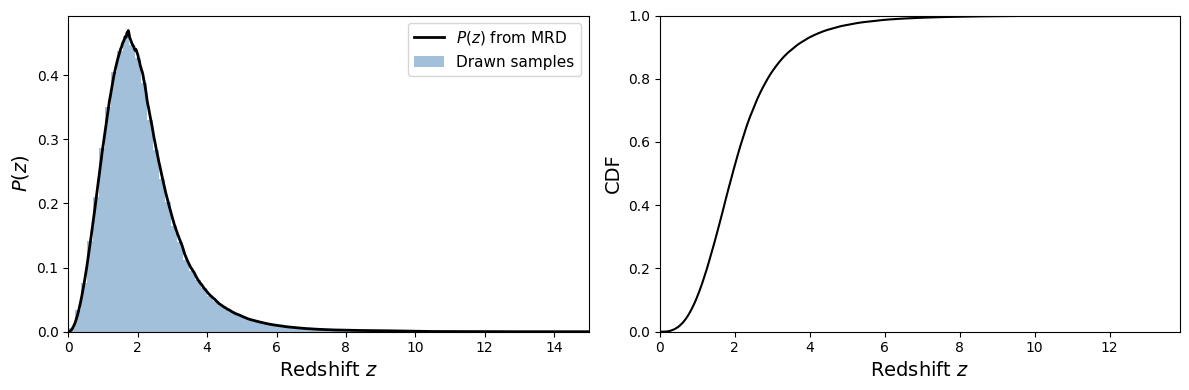

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left: P(z) distribution vs histogram of samples
ax1.plot(z_grid, P_z_density, 'k-', lw=2, label=r'$P(z)$ from MRD')
ax1.hist(z_samples, bins=80, density=True, alpha=0.5, color='steelblue', label='Drawn samples')
ax1.set_xlabel('Redshift $z$', fontsize=14)
ax1.set_ylabel('$P(z)$', fontsize=14)
ax1.legend(fontsize=11)
ax1.set_xlim(0, z_grid.max())

# Right: Cumulative distribution
z_sorted = np.sort(z_samples)
cdf = np.arange(1, len(z_sorted) + 1) / len(z_sorted)
ax2.plot(z_sorted, cdf, 'k-', lw=1.5)
ax2.set_xlabel('Redshift $z$', fontsize=14)
ax2.set_ylabel('CDF', fontsize=14)
ax2.set_xlim(0, max(z_sorted))
ax2.set_ylim(0, 1)
    
plt.tight_layout()
plt.show()